# 03 — Popularity Bias: Error Rate by Decile

Analyses how **accuracy** (= higher = better) varies across Wikipedia article popularity deciles for every backend and context-size combination.

**Sections:**
1. Accuracy by decile — all backends × context sizes
2. Popularity bias slope (linear regression)
3. RAG accuracy gain over zero-shot by decile
4. Heatmap: accuracy × backend × decile
5. Per-dataset accuracy by decile
6. Per-dataset accuracy + retrieval miss rate combined

In [ ]:
import sys, pathlib, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent))
from notebooks.full_pipe_eval.shared_setup import *

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from scipy import stats

# ── Plotting constants ────────────────────────────────────────────────────────
# One line style per ctx_label so same backend is visually grouped
_CTX_STYLE = {
    'zero': {'ls': '-',  'lw': 2.5, 'ms': 7,  'marker': 'D'},
    'top1': {'ls': '-',  'lw': 2.0, 'ms': 6,  'marker': 'o'},
    'top3': {'ls': '--', 'lw': 1.8, 'ms': 5,  'marker': 's'},
}
_DEFAULT_STYLE = {'ls': '-', 'lw': 1.5, 'ms': 5, 'marker': 'x'}

def _run_color(backend, ctx_label):
    base = backend_color(backend)
    # Slightly dim top3 lines so top1/zero stand out
    if ctx_label == 'top3':
        import matplotlib.colors as mc
        rgb = mc.to_rgb(base)
        return tuple(min(1.0, c + 0.25) for c in rgb)
    return base

def _run_label(backend, ctx_label):
    if ctx_label == 'zero':
        return backend
    return f'{backend}  ({ctx_label})'

def _compute_decile_stats(df, dcol, evaluator, llm, backend, ctx_label, n_deciles=10):
    """Return DataFrame with columns: decile, accuracy, ci95, n."""
    sub = df[
        (df['evaluator'] == evaluator) &
        (df['llm']       == llm) &
        (df['backend']   == backend) &
        (df['ctx_label'] == ctx_label)
    ].copy()
    sub['_d'] = sub[dcol].astype(float).round().astype(int)

    rows = []
    for d in range(n_deciles):
        bucket = sub[sub['_d'] == d]
        n = len(bucket)
        if n == 0:
            rows.append({'decile': d, 'accuracy': np.nan, 'ci95': np.nan, 'n': 0})
            continue
        acc = bucket['evaluation_score'].mean()
        se  = (acc * (1 - acc) / n) ** 0.5
        rows.append({'decile': d, 'accuracy': acc, 'ci95': 1.96 * se, 'n': n})
    return pd.DataFrame(rows)


N_DECILES  = 10
DECILES    = list(range(N_DECILES))
DCOL       = decile_col          # resolved by shared_setup
print(f"Using decile column: {DCOL!r}")
print(f"LLMs:     {LLM_KEYS}")
print(f"Backends: {BACKEND_KEYS}")
print(f"Ctx:      {CTX_LABELS}")
print(f"Evals:    {EVALUATOR_KEYS}")


## 1 — Accuracy by popularity decile

One line per (backend, context size). Accuracy = higher = better.  
Solid line = top1 context, dashed = top3, bold diamond = zero-shot.  
Shaded band = 95 % Wilson CI.  One figure per (LLM × evaluator).


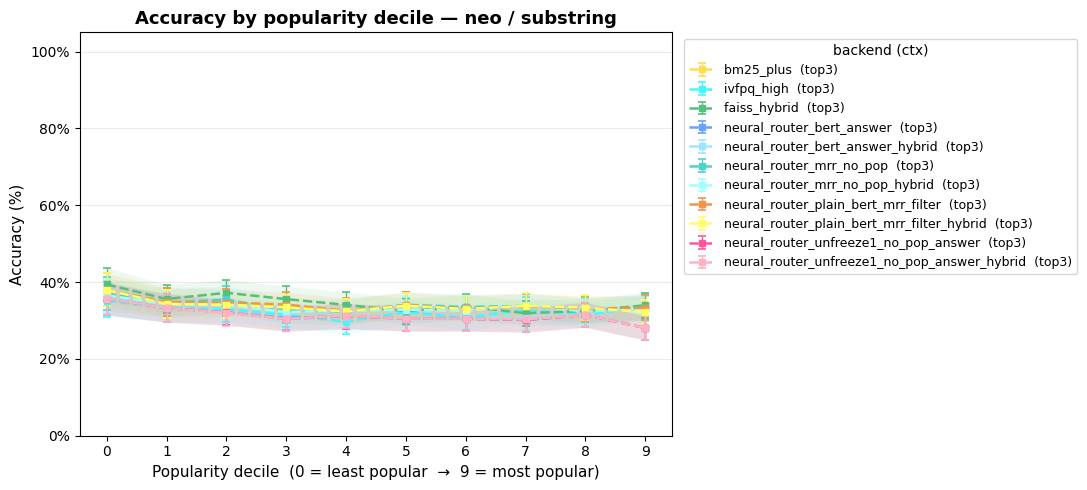

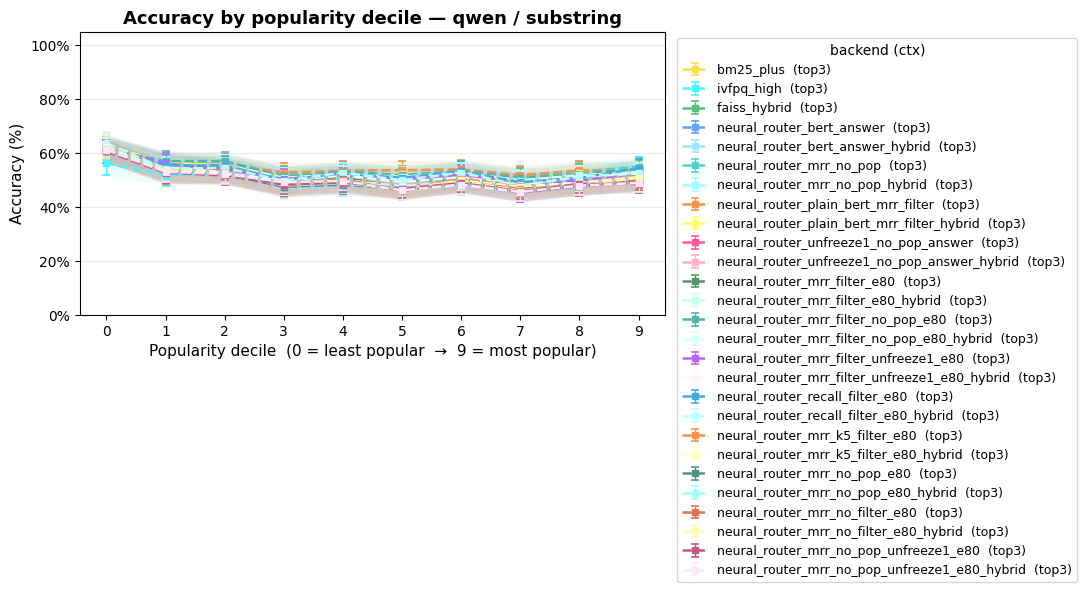

In [ ]:
for ev in EVALUATOR_KEYS:
    for llm in LLM_KEYS:
        fig, ax = plt.subplots(figsize=(11, 5))

        for backend in BACKEND_KEYS:
            ctx_list = [c for c in CTX_LABELS
                        if not (backend == 'zero_shot') or c == 'zero']
            ctx_list = [c for c in ctx_list
                        if not (backend != 'zero_shot' and c == 'zero')]

            for ctx in ctx_list:
                dt = _compute_decile_stats(results_all, DCOL, ev, llm, backend, ctx)
                if dt['n'].sum() == 0:
                    continue

                sty   = _CTX_STYLE.get(ctx, _DEFAULT_STYLE)
                color = _run_color(backend, ctx)
                label = _run_label(backend, ctx)

                # Draw CI band
                valid = dt['accuracy'].notna()
                ax.fill_between(
                    dt.loc[valid, 'decile'],
                    (dt.loc[valid, 'accuracy'] - dt.loc[valid, 'ci95']) * 100,
                    (dt.loc[valid, 'accuracy'] + dt.loc[valid, 'ci95']) * 100,
                    color=color, alpha=0.10, linewidth=0,
                )
                ax.errorbar(
                    dt['decile'], dt['accuracy'] * 100,
                    yerr=dt['ci95'] * 100,
                    label=label, color=color,
                    linestyle=sty['ls'], linewidth=sty['lw'],
                    marker=sty['marker'], markersize=sty['ms'],
                    capsize=3, capthick=1.2, elinewidth=1.0,
                )

        ax.set_xticks(DECILES)
        ax.set_xticklabels([str(d) for d in DECILES])
        ax.set_xlabel('Popularity decile  (0 = least popular  →  9 = most popular)', fontsize=11)
        ax.set_ylabel('Accuracy (%)', fontsize=11)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_ylim(0, 105)
        ax.set_title(f'Accuracy by popularity decile — {llm} / {ev}', fontsize=13, fontweight='bold')
        ax.legend(title='backend (ctx)', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
        ax.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f'accuracy_by_decile_{llm}_{ev}.png', bbox_inches='tight', dpi=150)
        plt.show()


## 2 — Popularity bias slope

Linear regression of accuracy on decile. Positive slope = bias toward popular articles (errors more common for obscure articles). Table sorted by slope.

In [ ]:
from scipy import stats as _stats

bias_rows = []
for ev in EVALUATOR_KEYS:
    for llm in LLM_KEYS:
        for backend in BACKEND_KEYS:
            ctx_list = (['zero'] if backend == 'zero_shot'
                        else [c for c in CTX_LABELS if c != 'zero'])
            for ctx in ctx_list:
                dt = _compute_decile_stats(results_all, DCOL, ev, llm, backend, ctx)
                dt = dt.dropna(subset=['accuracy'])
                if len(dt) < 3:
                    continue
                slope, _, r, p, _ = _stats.linregress(dt['decile'], dt['accuracy'])
                low  = dt[dt['decile'] <= 2]['accuracy'].mean()
                high = dt[dt['decile'] >= 7]['accuracy'].mean()
                bias_rows.append({
                    'llm': llm, 'evaluator': ev,
                    'backend': backend, 'ctx': ctx,
                    'slope': slope, 'r': r, 'p': p,
                    'acc_low_deciles':  low,
                    'acc_high_deciles': high,
                    'delta (high−low)':   high - low,
                })

bias_df = pd.DataFrame(bias_rows)
if bias_df.empty:
    print('No data.')
else:
    bias_df = bias_df.sort_values('delta (high−low)', ascending=False)
    fmts = {'slope': '{:.4f}', 'r': '{:.3f}', 'p': '{:.3f}',
            'acc_low_deciles': '{:.1%}', 'acc_high_deciles': '{:.1%}',
            'delta (high−low)': '{:.1%}'}
    display_df = bias_df.copy()
    for col, fmt in fmts.items():
        display_df[col] = bias_df[col].map(lambda v, f=fmt: f.format(v))
    print(display_df[[
        'llm','evaluator','backend','ctx',
        'slope','r','p',
        'acc_low_deciles','acc_high_deciles','delta (high−low)'
    ]].to_string(index=False))


 llm evaluator                                       backend  ctx   slope      r     p acc_low_deciles acc_high_deciles delta (high−low)
 neo substring                                    ivfpq_high top3 -0.0017 -0.325 0.360           33.8%            32.6%            -1.2%
 neo substring               neural_router_mrr_no_pop_hybrid top3 -0.0027 -0.613 0.060           35.0%            33.1%            -1.8%
 neo substring    neural_router_plain_bert_mrr_filter_hybrid top3 -0.0036 -0.687 0.028           35.5%            33.1%            -2.4%
 neo substring                      neural_router_mrr_no_pop top3 -0.0031 -0.649 0.042           35.7%            33.2%            -2.4%
 neo substring           neural_router_plain_bert_mrr_filter top3 -0.0037 -0.725 0.018           35.8%            33.4%            -2.4%
qwen substring                                    ivfpq_high top3 -0.0033 -0.399 0.253           53.5%            50.7%            -2.8%
 neo substring  neural_router_unfreeze1_n

## 3 — RAG accuracy gain over zero-shot by decile

For each retrieval run, `delta = zero_shot_error − rag_error`.  Positive = RAG helped, negative = RAG hurt. Shows whether retrieval helps more for obscure (low-decile) articles.

In [ ]:
for ev in EVALUATOR_KEYS:
    for llm in LLM_KEYS:
        # Zero-shot baseline
        zs_dt = _compute_decile_stats(results_all, DCOL, ev, llm, 'zero_shot', 'zero')
        zs = zs_dt[['decile', 'accuracy', 'ci95']].rename(
            columns={'accuracy': 'zs_acc', 'ci95': 'zs_ci'})

        if zs['zs_acc'].isna().all():
            print(f'No zero-shot data for {llm}/{ev} — skipping §3.')
            continue

        fig, ax = plt.subplots(figsize=(11, 5))
        ax.axhline(0, color='black', linewidth=1.0, linestyle='--', zorder=2)

        rag_backends = [b for b in BACKEND_KEYS if b != 'zero_shot']
        for backend in rag_backends:
            ctx_list = [c for c in CTX_LABELS if c != 'zero']
            for ctx in ctx_list:
                dt = _compute_decile_stats(results_all, DCOL, ev, llm, backend, ctx)
                merged = dt.merge(zs, on='decile')
                merged['delta'] = merged['accuracy'] - merged['zs_acc']   # positive = RAG helped
                # Combined CI (root sum of squares)
                merged['delta_ci'] = np.sqrt(merged['ci95']**2 + merged['zs_ci']**2)

                sty   = _CTX_STYLE.get(ctx, _DEFAULT_STYLE)
                color = _run_color(backend, ctx)
                label = _run_label(backend, ctx)

                valid = merged['delta'].notna()
                ax.fill_between(
                    merged.loc[valid, 'decile'],
                    (merged.loc[valid, 'delta'] - merged.loc[valid, 'delta_ci']) * 100,
                    (merged.loc[valid, 'delta'] + merged.loc[valid, 'delta_ci']) * 100,
                    color=color, alpha=0.10, linewidth=0,
                )
                ax.errorbar(
                    merged['decile'], merged['delta'] * 100,
                    yerr=merged['delta_ci'] * 100,
                    label=label, color=color,
                    linestyle=sty['ls'], linewidth=sty['lw'],
                    marker=sty['marker'], markersize=sty['ms'],
                    capsize=3, capthick=1.2, elinewidth=1.0,
                )

        ax.set_xticks(DECILES)
        ax.set_xlabel('Popularity decile  (0 = least popular  →  9 = most popular)', fontsize=11)
        ax.set_ylabel('Accuracy gain over zero-shot  (pp)', fontsize=11)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_title(f'RAG accuracy gain over zero-shot — {llm} / {ev}', fontsize=13, fontweight='bold')
        ax.legend(title='backend (ctx)', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
        ax.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f'rag_accuracy_gain_{llm}_{ev}.png', bbox_inches='tight', dpi=150)
        plt.show()


No zero-shot data for neo/substring — skipping §3.
No zero-shot data for qwen/substring — skipping §3.


## 4 — Heatmap: accuracy by backend × decile

One heatmap per (LLM × evaluator). Each cell is the mean accuracy across context sizes for that backend+decile combination. Darker = more errors.

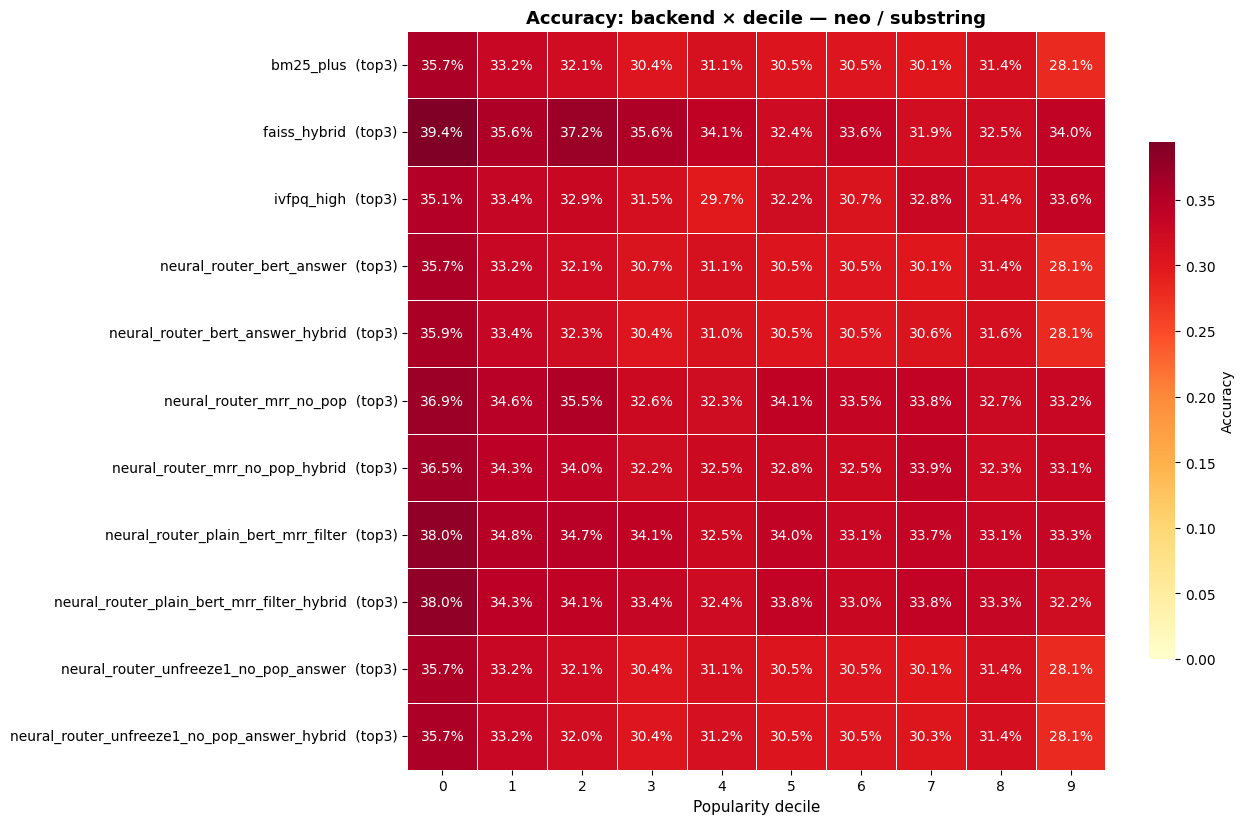

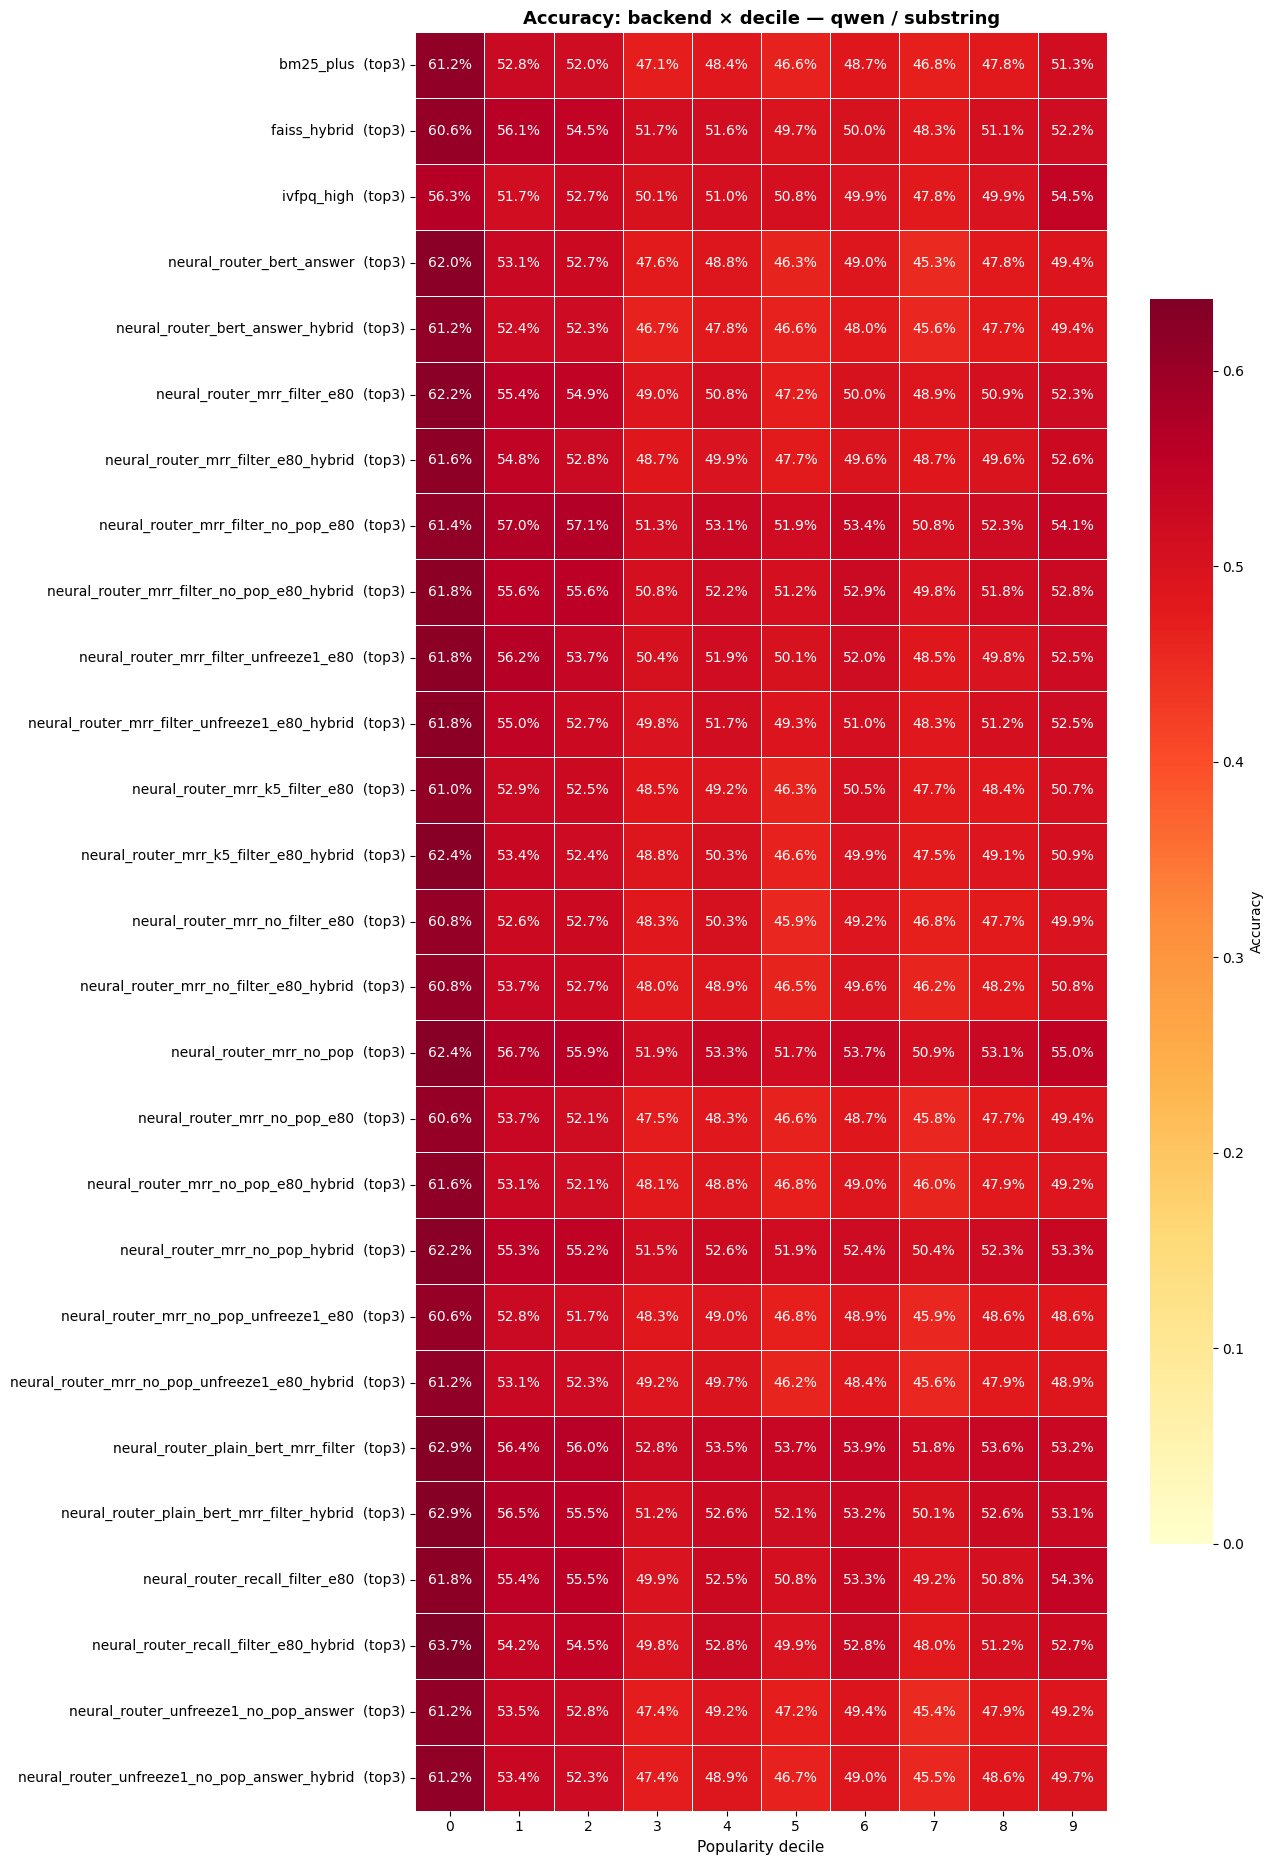

In [ ]:
for ev in EVALUATOR_KEYS:
    for llm in LLM_KEYS:
        rows = []
        for backend in BACKEND_KEYS:
            ctx_list = (['zero'] if backend == 'zero_shot'
                        else [c for c in CTX_LABELS if c != 'zero'])
            for ctx in ctx_list:
                dt = _compute_decile_stats(results_all, DCOL, ev, llm, backend, ctx)
                for _, r in dt.iterrows():
                    rows.append({'run': _run_label(backend, ctx),
                                 'decile': int(r['decile']),
                                 'accuracy': r['accuracy']})

        if not rows:
            continue
        heat_df = pd.DataFrame(rows)
        piv = heat_df.pivot_table(index='run', columns='decile',
                                  values='accuracy', aggfunc='mean')
        # Sort rows: zero_shot first, then alphabetically
        order = (['zero_shot'] +
                 sorted([r for r in piv.index if 'zero_shot' not in r]))
        piv = piv.reindex([r for r in order if r in piv.index])

        fig, ax = plt.subplots(figsize=(13, max(3, len(piv) * 0.65 + 1.2)))
        import seaborn as sns
        sns.heatmap(
            piv, annot=True, fmt='.1%', cmap='YlOrRd',
            ax=ax, vmin=0, vmax=piv.values[~np.isnan(piv.values)].max(),
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Accuracy', 'shrink': 0.7},
        )
        ax.set_xlabel('Popularity decile', fontsize=11)
        ax.set_ylabel('')
        ax.set_title(f'Accuracy: backend × decile — {llm} / {ev}',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f'heatmap_accuracy_{llm}_{ev}.png', bbox_inches='tight', dpi=150)
        plt.show()


## 5 — Per-dataset accuracy by decile

Same line chart as §1 but faceted by QA dataset. One subplot per dataset, all backends overlaid.

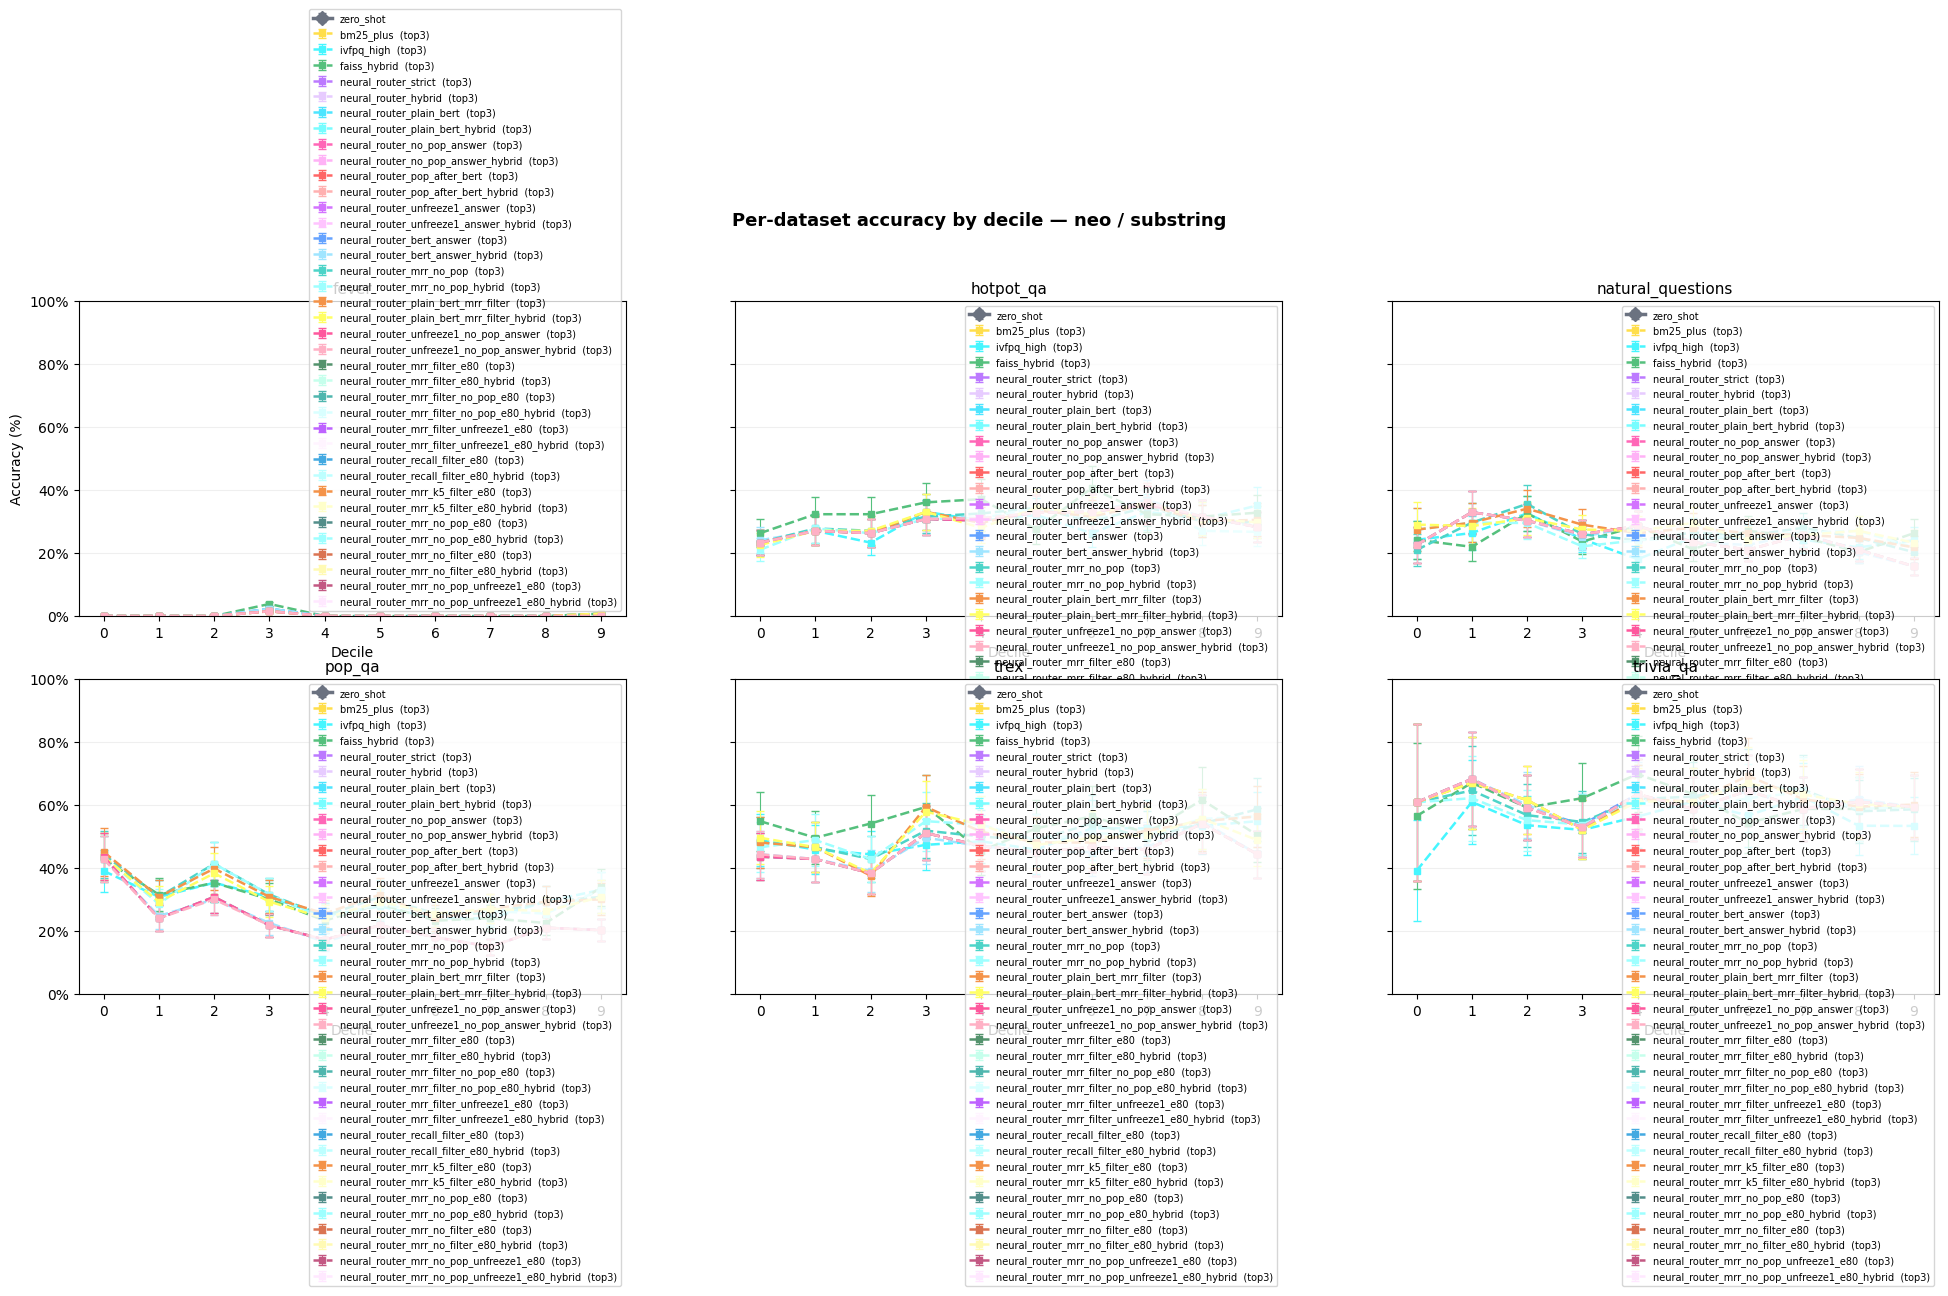

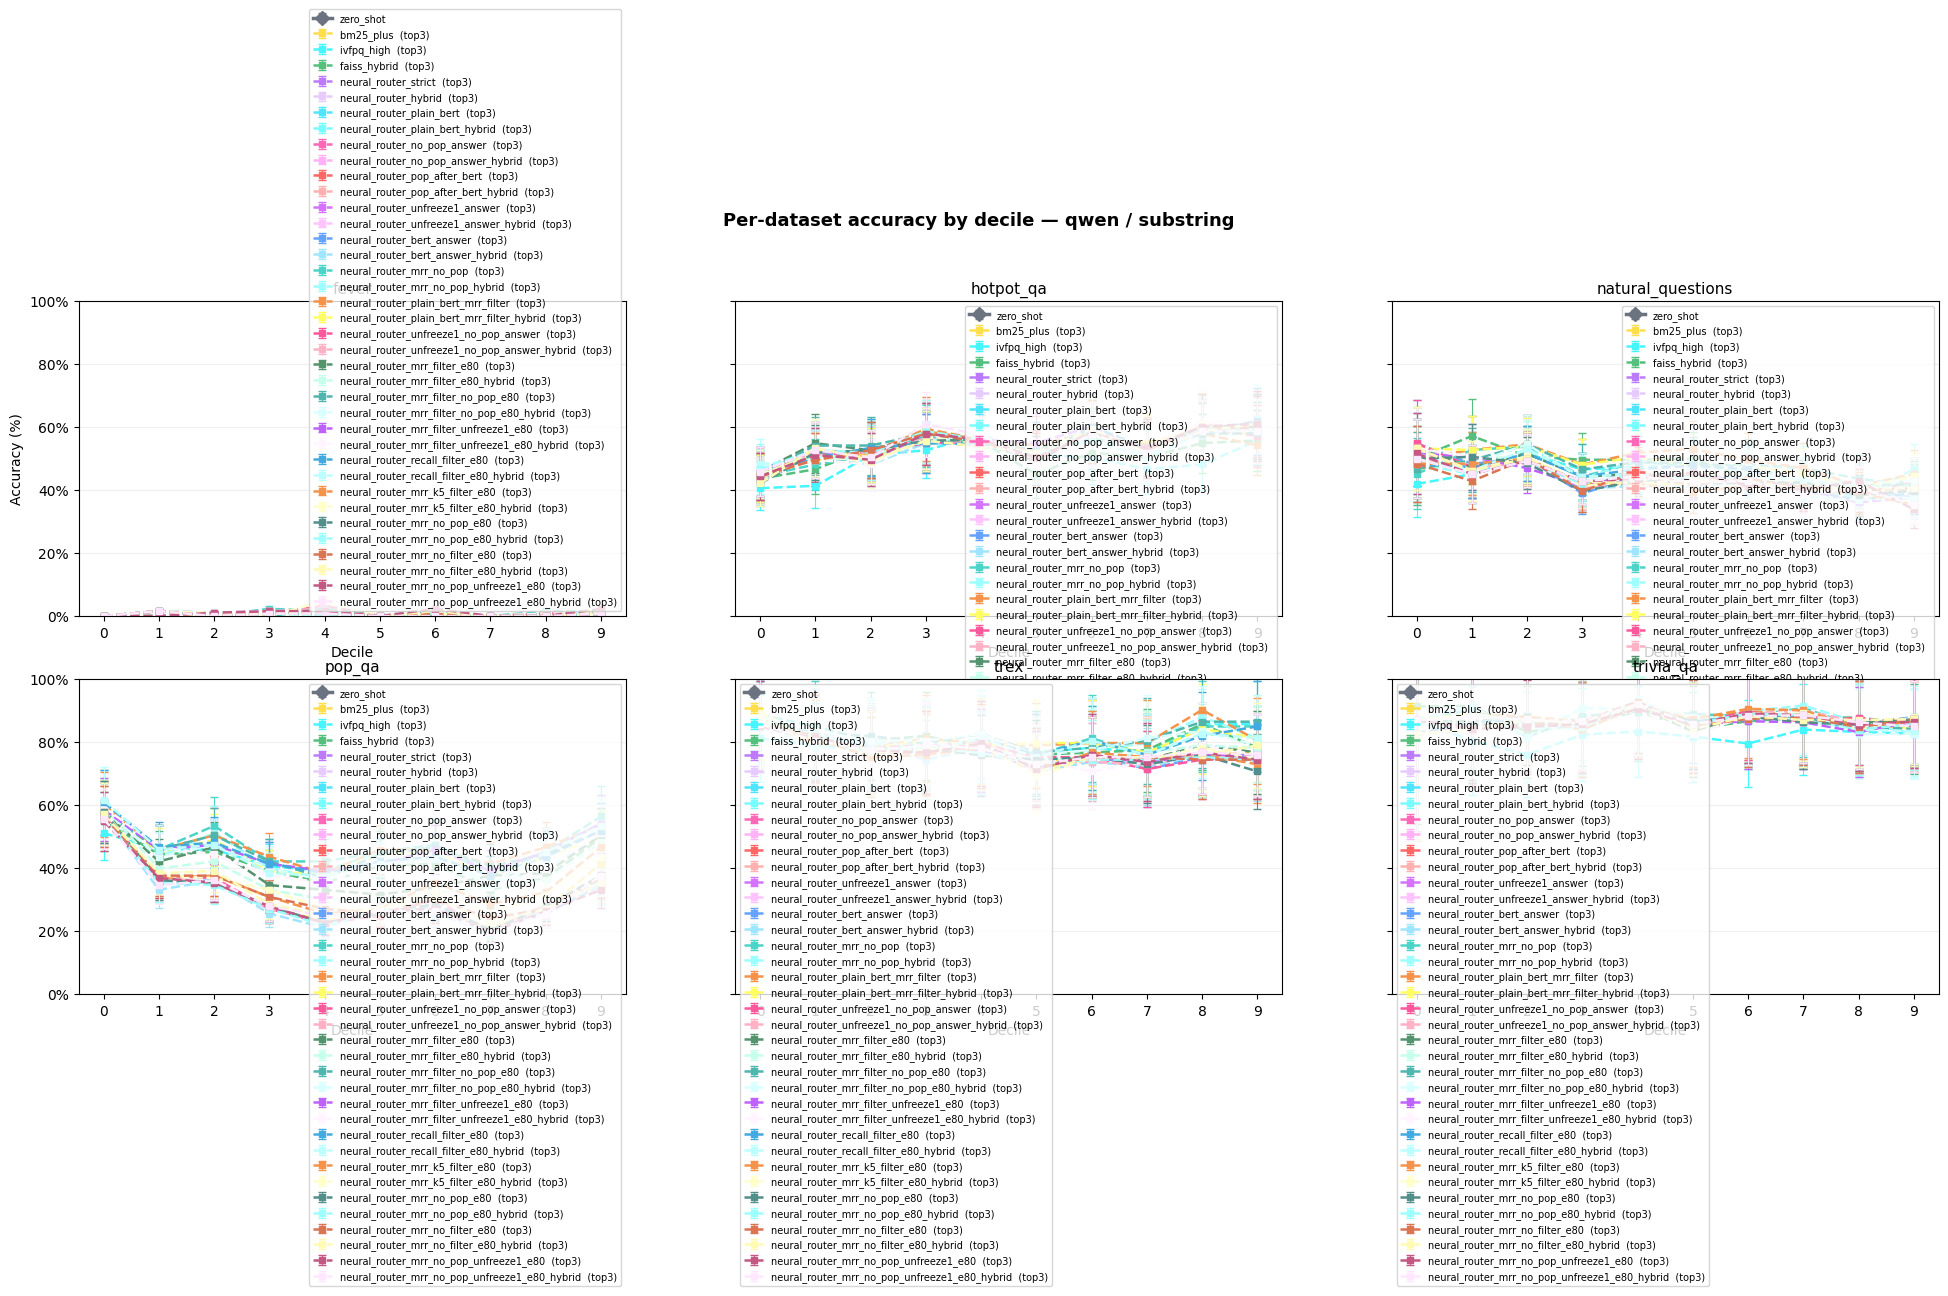

In [ ]:
for ev in EVALUATOR_KEYS:
    for llm in LLM_KEYS:
        df_ll = results_all[
            (results_all['evaluator'] == ev) &
            (results_all['llm']       == llm)
        ].copy()

        if 'dataset' not in df_ll.columns:
            print(f'[{llm}/{ev}] No dataset column — skipping §5.')
            continue

        datasets = sorted(df_ll['dataset'].dropna().unique())
        if len(datasets) <= 1:
            print(f'[{llm}/{ev}] Only one dataset — skipping §5.')
            continue

        df_ll['_d'] = df_ll[DCOL].astype(float).round().astype(int)

        ncols = min(len(datasets), 3)
        nrows = -(-len(datasets) // ncols)   # ceiling division
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(8 * ncols, 4.5 * nrows),
                                 sharey=True, squeeze=False)

        for idx, ds in enumerate(datasets):
            r, c = divmod(idx, ncols)
            ax = axes[r][c]
            sub_ds = df_ll[df_ll['dataset'] == ds]

            for backend in BACKEND_KEYS:
                ctx_list = (['zero'] if backend == 'zero_shot'
                            else [c for c in CTX_LABELS if c != 'zero'])
                for ctx in ctx_list:
                    sub = sub_ds[sub_ds['backend'] == backend][sub_ds['ctx_label'] == ctx]
                    rows = []
                    for d in DECILES:
                        bucket = sub[sub['_d'] == d]
                        n = len(bucket)
                        if n == 0:
                            rows.append({'decile': d, 'acc': np.nan, 'ci': np.nan})
                            continue
                        acc = bucket['evaluation_score'].mean()
                        se  = (acc * (acc) / n) ** 0.5
                        rows.append({'decile': d, 'acc': (acc)*100, 'ci': 1.96*se*100})
                    dt = pd.DataFrame(rows)

                    sty   = _CTX_STYLE.get(ctx, _DEFAULT_STYLE)
                    color = _run_color(backend, ctx)
                    ax.errorbar(
                        dt['decile'], dt['acc'], yerr=dt['ci'],
                        label=_run_label(backend, ctx), color=color,
                        linestyle=sty['ls'], linewidth=sty['lw'],
                        marker=sty['marker'], markersize=sty['ms'],
                        capsize=3, capthick=1.0, elinewidth=0.8,
                    )

            ax.set_title(ds, fontsize=11)
            ax.set_xticks(DECILES)
            ax.set_xlabel('Decile')
            ax.set_ylim(0, 100)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter())
            ax.grid(axis='y', alpha=0.2)
            ax.legend(fontsize=7)

        for idx in range(len(datasets), nrows * ncols):
            r, c = divmod(idx, ncols)
            axes[r][c].axis('off')

        axes[0][0].set_ylabel('Accuracy (%)')
        fig.suptitle(
            f'Per-dataset accuracy by decile — {llm} / {ev}',
            fontsize=13, fontweight='bold',
        )
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f'dataset_decile_accuracy_{llm}_{ev}.png', bbox_inches='tight', dpi=150)
        plt.show()


## 6 — Per-dataset: accuracy + retrieval recall across deciles

Solid line = accuracy. Dashed line = retrieval recall (miss rate = 1 − recall shown on same axis). Only retrieval backends show a recall line.

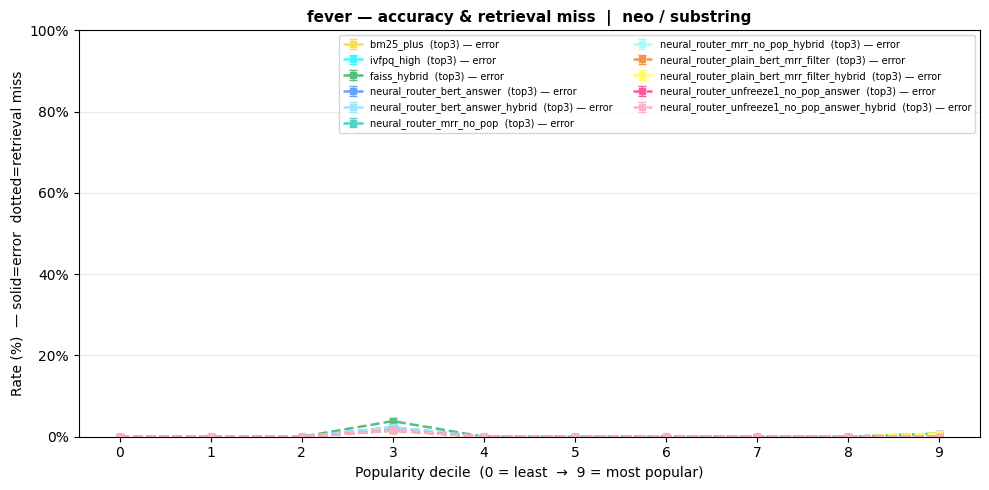

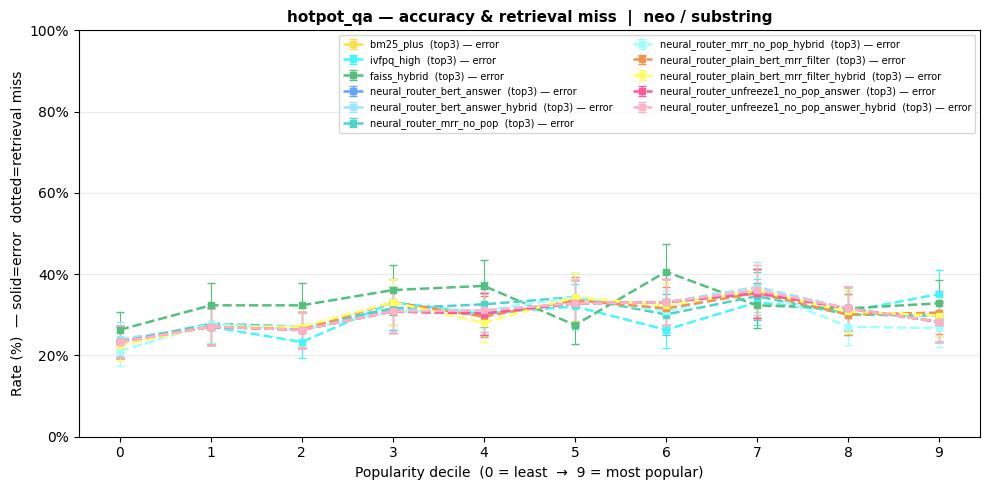

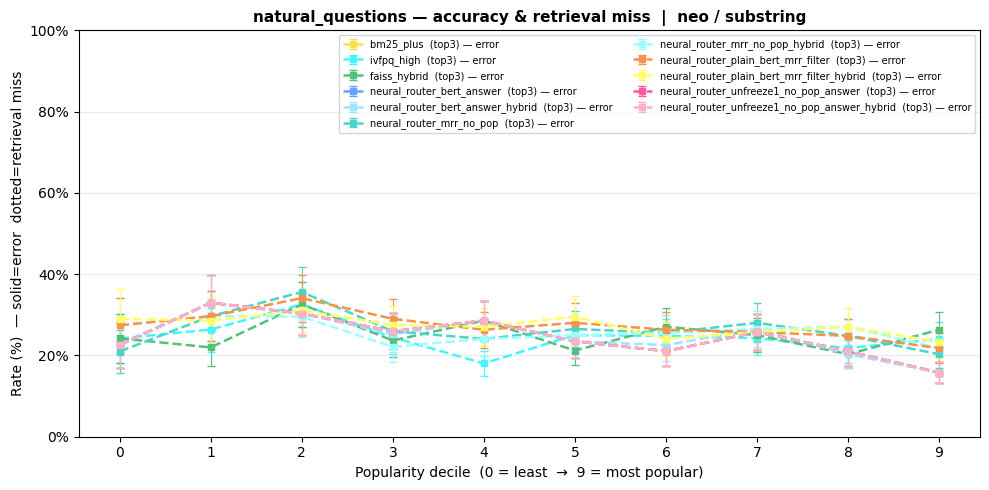

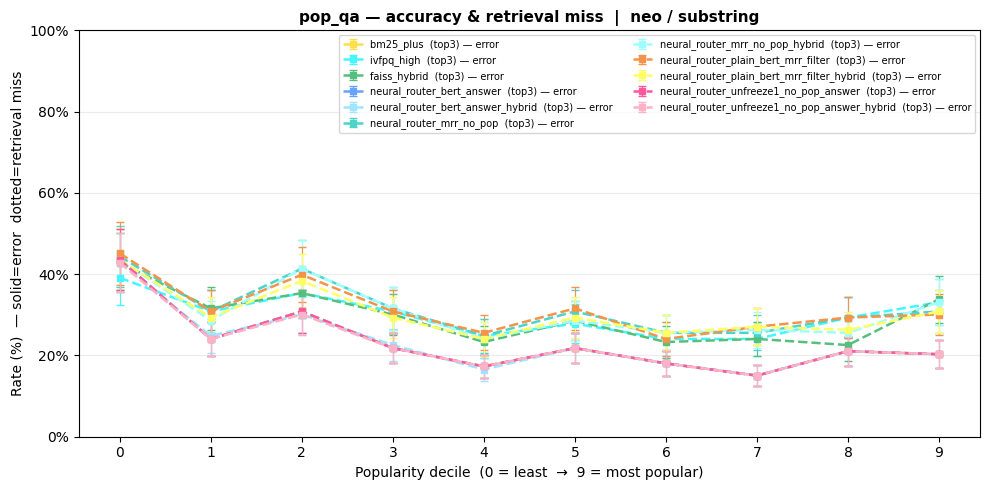

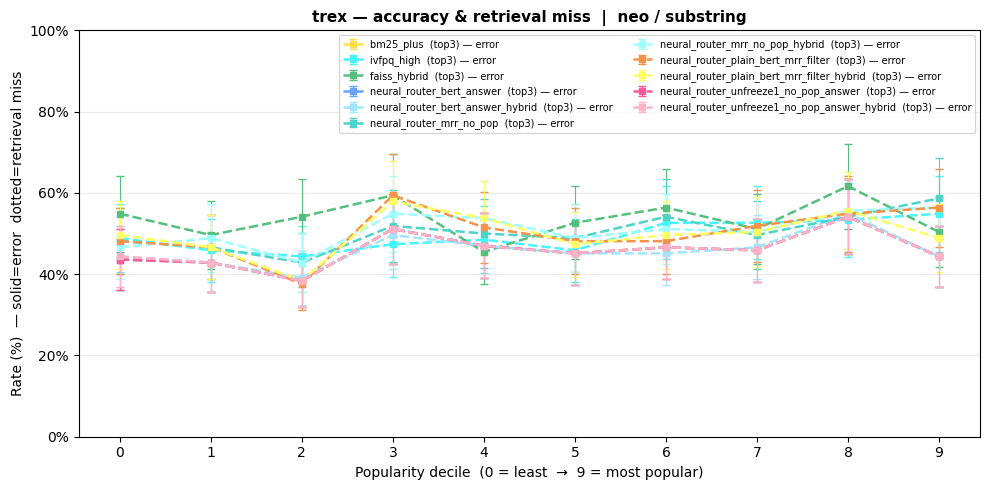

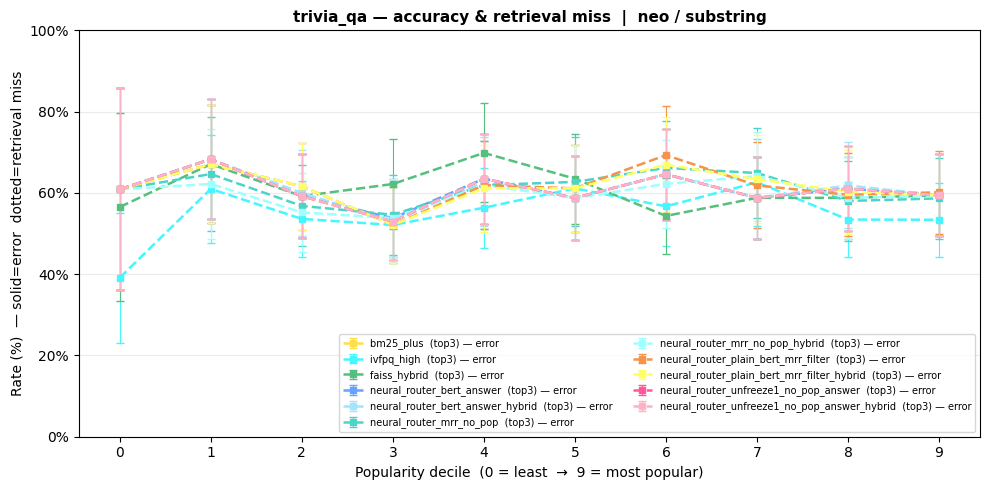

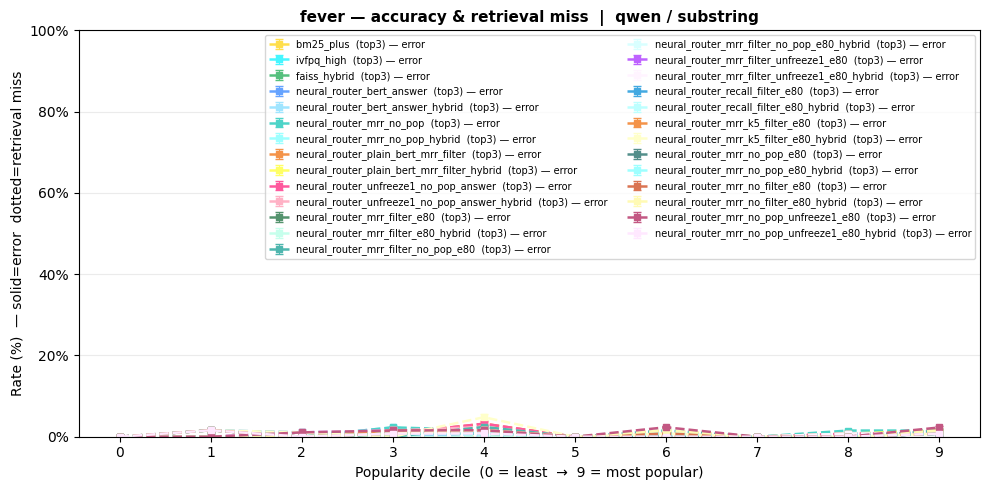

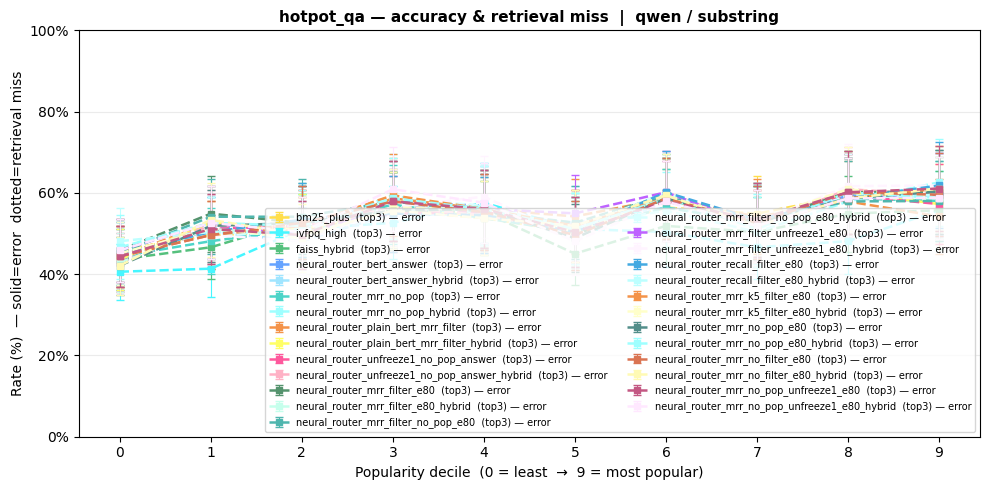

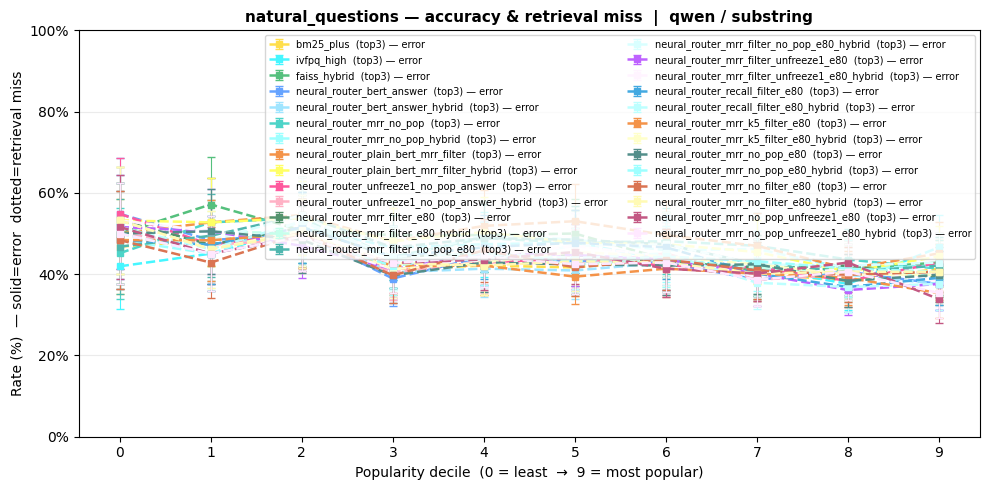

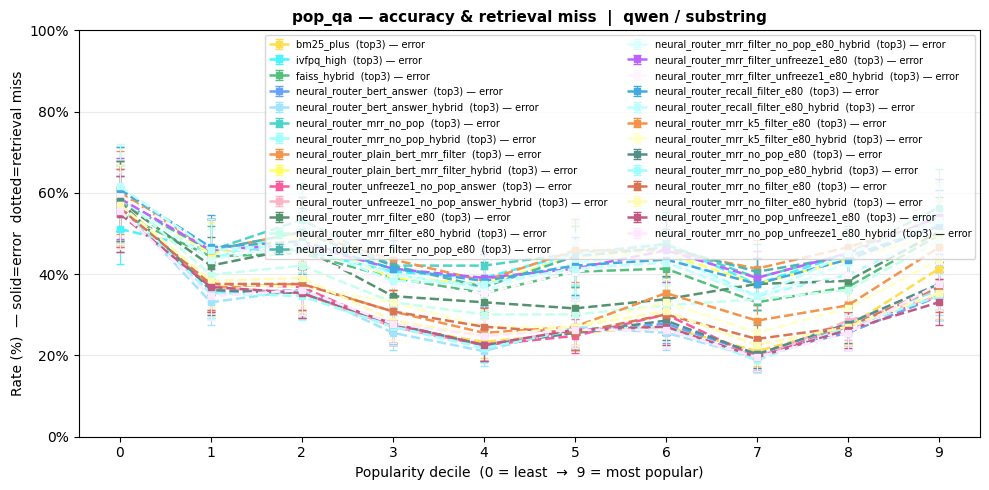

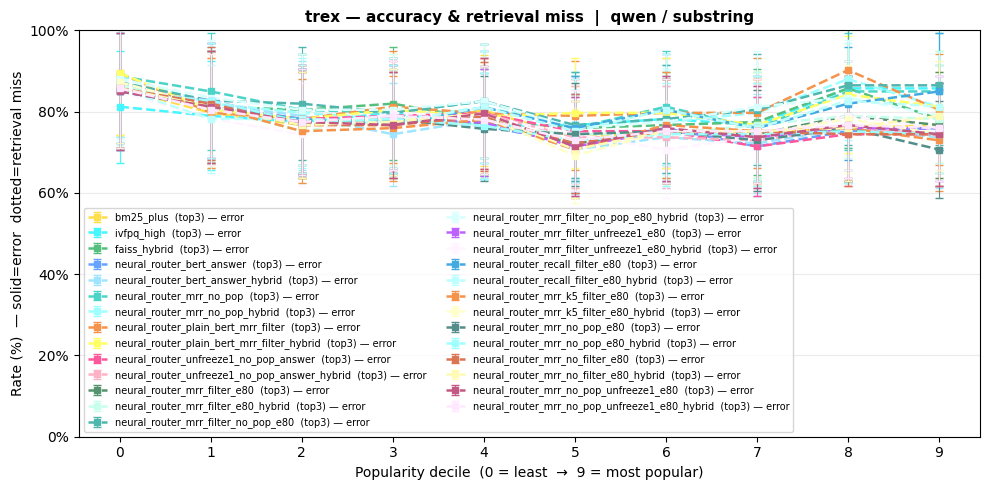

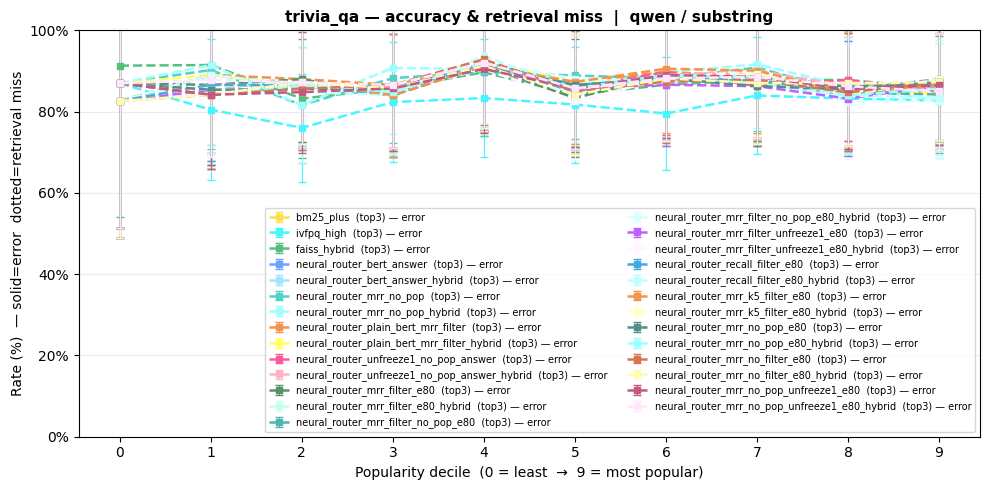

In [ ]:
def _ensure_hit(df):
    df = df.copy()
    if 'hit' in df.columns and df['hit'].notna().any():
        return df
    if 'retrieved_doc_ids' not in df.columns:
        df['hit'] = np.nan
        return df
    if 'wikipedia_id_int' not in df.columns:
        df['wikipedia_id_int'] = pd.to_numeric(df.get('wikipedia_id', pd.Series(dtype=float)), errors='coerce')
    def _h(r):
        ids = r.get('retrieved_doc_ids')
        wid = r.get('wikipedia_id_int')
        if not isinstance(ids, list) or len(ids) == 0 or pd.isna(wid):
            return np.nan
        try:
            return int(wid) in [int(x) for x in ids]
        except Exception:
            return np.nan
    df['hit'] = df.apply(_h, axis=1)
    return df

for ev in EVALUATOR_KEYS:
    df_ev = _ensure_hit(results_all[results_all['evaluator'] == ev].copy())

    if 'dataset' not in df_ev.columns:
        continue
    datasets = sorted(df_ev['dataset'].dropna().unique())
    df_ev['_d'] = df_ev[DCOL].astype(float).round().astype(int)

    has_retrieval = df_ev['hit'].notna().any()

    for llm in LLM_KEYS:
        df_ll = df_ev[df_ev['llm'] == llm]

        for ds in datasets:
            df_ds = df_ll[df_ll['dataset'] == ds]
            if df_ds.empty:
                continue

            fig, ax = plt.subplots(figsize=(10, 5))

            for backend in BACKEND_KEYS:
                ctx_list = (['zero'] if backend == 'zero_shot'
                            else [c for c in CTX_LABELS if c != 'zero'])
                for ctx in ctx_list:
                    sub = df_ds[(df_ds['backend'] == backend) & (df_ds['ctx_label'] == ctx)]
                    if sub.empty:
                        continue
                    color = _run_color(backend, ctx)
                    sty   = _CTX_STYLE.get(ctx, _DEFAULT_STYLE)
                    label = _run_label(backend, ctx)

                    rows = []
                    for d in DECILES:
                        bucket = sub[sub['_d'] == d]
                        n = len(bucket)
                        if n == 0:
                            rows.append({'decile': d, 'acc': np.nan, 'acc_ci': np.nan,
                                         'miss': np.nan, 'miss_ci': np.nan})
                            continue
                        acc = bucket['evaluation_score'].mean()
                        err_ci = 1.96 * (acc*(acc)/n)**0.5
                        hit_vals = bucket['hit'].dropna()
                        if len(hit_vals) > 0 and has_retrieval and backend != 'zero_shot':
                            rec = hit_vals.mean()
                            miss = 1 - rec
                            miss_ci = 1.96 * (rec*(1-rec)/len(hit_vals))**0.5
                        else:
                            miss = miss_ci = np.nan
                        rows.append({'decile': d,
                                     'acc': (acc)*100, 'acc_ci': err_ci*100,
                                     'miss': miss*100 if not np.isnan(miss) else np.nan,
                                     'miss_ci': miss_ci*100 if not np.isnan(miss_ci) else np.nan})
                    dt = pd.DataFrame(rows)

                    ax.errorbar(dt['decile'], dt['acc'], yerr=dt['acc_ci'],
                                label=f'{label} — error', color=color,
                                linestyle=sty['ls'], linewidth=sty['lw'],
                                marker=sty['marker'], markersize=sty['ms'],
                                capsize=3, capthick=1.0, elinewidth=0.8)

                    if dt['miss'].notna().any():
                        ax.errorbar(dt['decile'], dt['miss'], yerr=dt['miss_ci'],
                                    label=f'{label} — miss', color=color,
                                    linestyle=':', linewidth=1.4,
                                    marker=sty['marker'], markersize=4,
                                    capsize=2, capthick=0.8, elinewidth=0.7, alpha=0.65)

            ax.set_xticks(DECILES)
            ax.set_ylim(0, 100)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter())
            ax.set_xlabel('Popularity decile  (0 = least  →  9 = most popular)', fontsize=10)
            ax.set_ylabel('Rate (%)  — solid=error  dotted=retrieval miss', fontsize=10)
            ax.set_title(f'{ds} — accuracy & retrieval miss  |  {llm} / {ev}',
                         fontsize=11, fontweight='bold')
            ax.legend(fontsize=7, ncol=2, loc='best')
            ax.grid(axis='y', alpha=0.25)
            plt.tight_layout()
            safe = ds.replace('/', '_').replace(' ', '_')
            plt.savefig(IMAGES_DIR / f'ds_decile_acc_recall_{llm}_{ev}_{safe}.png',
                        bbox_inches='tight', dpi=150)
            plt.show()


## 7 — Backend comparison by popularity bucket × dataset

For each QA dataset and popularity bucket (low = deciles 0–2, medium = 3–6, high = 7–9)
we report the accuracy of every backend and the **delta vs `faiss_hybrid`** — the
non-router hybrid baseline. The best-scoring backend per row is highlighted in
**bold gold**, deltas better than baseline are **green**, worse are **red**.

Use this table to see which router model wins where the standard hybrid struggles
(typically low-popularity slices).

In [ ]:
# ── Backend × dataset × popularity-bucket comparison ──────────────────────────
# Buckets: low = deciles 0–2, medium = 3–6, high = 7–9
# Adds 4 summary rows at the bottom of each table:
#   • ALL — low / medium / high   (per-bucket aggregate across all datasets)
#   • ALL — overall               (single overall accuracy across all data)
import pandas as pd
import numpy as np

BUCKETS = {
    "low (0–2)":    [0, 1, 2],
    "medium (3–6)": [3, 4, 5, 6],
    "high (7–9)":   [7, 8, 9],
}
BASELINE = "faiss_hybrid"   # non-router hybrid baseline
MIN_ROWS = 5                # backends with < MIN_ROWS of data in this slice are dropped
_OVERALL_BUCKET = "overall" # tag for the "overall" pseudo bucket


def _ctx_for(backend):
    """Pick the ctx_label to use for a given backend (zero_shot→'zero', else first non-zero)."""
    if backend == "zero_shot":
        return "zero"
    return next((c for c in CTX_LABELS if c != "zero"), None)


def _weighted_acc(df_slice, backend, ctx):
    """Question-count-weighted accuracy of one backend over a slice."""
    if ctx is None:
        return np.nan
    sub = df_slice[(df_slice["backend"] == backend) & (df_slice["ctx_label"] == ctx)]
    n = len(sub)
    if n == 0:
        return np.nan
    return float(sub["evaluation_score"].mean())


for ev in EVALUATOR_KEYS:
    df_ev = results_all[results_all["evaluator"] == ev].copy()
    df_ev = df_ev[df_ev["dataset"] != "hotpot_qa"]
    df_ev = df_ev[df_ev["dataset"] != "trex"]
    df_ev = df_ev[df_ev["dataset"] != "fever"]
    if "dataset" not in df_ev.columns:
        print(f"No 'dataset' column — skipping {ev}")
        continue

    df_ev["_d"] = df_ev[DCOL].astype(float).round().astype(int)
    datasets = sorted(df_ev["dataset"].dropna().unique())

    for llm in LLM_KEYS:
        df_ll = df_ev[df_ev["llm"] == llm]

        # ── 1. Determine which backends actually have data for this (llm, ev) ──
        available_backends = [
            b for b in BACKEND_KEYS
            if b != "zero_shot"
            and (df_ll["backend"] == b).sum() >= MIN_ROWS
        ]
        if BASELINE not in available_backends:
            print(f"[{llm}/{ev}] baseline '{BASELINE}' has no data — skipping")
            continue
        routers = [b for b in available_backends if b != BASELINE]
        if not routers:
            print(f"[{llm}/{ev}] no router backends have data — skipping")
            continue

        # ── 2. Per-(dataset, bucket) accuracy rows ─────────────────────────────
        rows = []
        for ds in datasets:
            df_ds = df_ll[df_ll["dataset"] == ds]
            for bucket_name, decs in BUCKETS.items():
                df_b = df_ds[df_ds["_d"].isin(decs)]
                row = {"dataset": ds, "bucket": bucket_name}
                for backend in available_backends:
                    row[backend] = _weighted_acc(df_b, backend, _ctx_for(backend))
                rows.append(row)

        # ── 3. Aggregate "ALL" rows — per-bucket and overall ──────────────────
        for bucket_name, decs in BUCKETS.items():
            df_b = df_ll[df_ll["_d"].isin(decs)]
            row = {"dataset": "ALL", "bucket": bucket_name}
            for backend in available_backends:
                row[backend] = _weighted_acc(df_b, backend, _ctx_for(backend))
            rows.append(row)

        # Overall (all deciles, all datasets)
        row = {"dataset": "ALL", "bucket": _OVERALL_BUCKET}
        for backend in available_backends:
            row[backend] = _weighted_acc(df_ll, backend, _ctx_for(backend))
        rows.append(row)

        cmp_df = pd.DataFrame(rows)
        if cmp_df.empty:
            continue

        # ── 4. Build display table: acc% + (Δ vs baseline) ────────────────────
        display_df = pd.DataFrame()
        display_df["dataset"] = cmp_df["dataset"]
        display_df["bucket"]  = cmp_df["bucket"]
        for backend in available_backends:
            acc_pct = cmp_df[backend] * 100.0
            if backend == BASELINE:
                display_df[backend] = acc_pct.map(lambda v: f"{v:.1f}" if pd.notna(v) else "—")
            else:
                delta = (cmp_df[backend] - cmp_df[BASELINE]) * 100.0
                display_df[backend] = [
                    f"{a:.1f} ({d:+.1f})" if pd.notna(a) and pd.notna(d) else "—"
                    for a, d in zip(acc_pct, delta)
                ]

        # ── 5. Best router per row (excluding the baseline column) ────────────
        best_per_row = cmp_df[routers].idxmax(axis=1)

        # ── 6. Identify which rows are "ALL" aggregates ───────────────────────
        agg_mask = (cmp_df["dataset"] == "ALL")
        n_data_rows = (~agg_mask).sum()

        # ── 7. Styled render ──────────────────────────────────────────────────
        def _highlight(df_disp):
            out = pd.DataFrame("", index=df_disp.index, columns=df_disp.columns)
            for r in df_disp.index:
                is_agg_row = (cmp_df.loc[r, "dataset"] == "ALL")
                for backend in available_backends:
                    val = df_disp.loc[r, backend]
                    if val == "—":
                        continue
                    if backend == BASELINE:
                        out.loc[r, backend] = (
                            "background-color: #F1F5F9; font-weight: bold; color: #111827"
                        )
                        continue
                    delta = (cmp_df.loc[r, backend] - cmp_df.loc[r, BASELINE]) * 100
                    is_best = (best_per_row.iloc[r] == backend)
                    if delta > 0.5:
                        color = "#15803D"   # green
                    elif delta < -0.5:
                        color = "#B91C1C"   # red
                    else:
                        color = "#374151"
                    bg = "background-color: #FEF3C7;" if is_best else ""
                    agg_extra = "border-top: 2px solid #94A3B8;" if is_agg_row else ""
                    out.loc[r, backend] = f"color: {color}; font-weight: 600; {bg} {agg_extra}"
                if is_agg_row:
                    out.loc[r, "dataset"] = "font-weight: bold; background-color: #E0E7FF"
                    out.loc[r, "bucket"]  = "font-weight: bold; background-color: #E0E7FF"
            return out

        styler = (
            display_df.style
            .apply(_highlight, axis=None)
            .set_caption(
                f"Accuracy (%) with Δ vs {BASELINE}  —  {llm} / {ev}  "
                "(gold = best router, green = beats baseline, red = worse, "
                "ALL rows aggregate across all datasets)"
            )
            .set_properties(
                **{"text-align": "center", "font-family": "monospace", "font-size": "11px"}
            )
            .set_table_styles([
                {"selector": "caption",
                 "props": [("caption-side", "top"), ("font-weight", "bold"),
                           ("font-size", "13px"), ("padding", "8px")]},
                {"selector": "th",
                 "props": [("font-size", "11px"), ("padding", "4px 6px"),
                           ("background-color", "#F9FAFB")]},
            ])
        )

        print(f"\n{'═' * 100}")
        print(f"  {llm.upper()}  /  {ev}  — accuracy (%) by dataset × popularity bucket")
        print(f"  Backends shown: {len(available_backends)} "
              f"(1 baseline + {len(routers)} routers with data)")
        print(f"  Showing {n_data_rows} dataset rows + 4 aggregate rows (ALL × low/med/high/overall)")
        print(f"{'═' * 100}")
        display(styler)

        # Save raw values for downstream use
        out_csv = IMAGES_DIR.parent / f"backend_comparison_{llm}_{ev}.csv"
        cmp_df.to_csv(out_csv, index=False)
        print(f"  ↳ saved {out_csv}")



════════════════════════════════════════════════════════════════════════════════════════════════════
  NEO  /  substring  — accuracy (%) by dataset × popularity bucket
  Backends shown: 11 (1 baseline + 10 routers with data)
  Showing 9 dataset rows + 4 aggregate rows (ALL × low/med/high/overall)
════════════════════════════════════════════════════════════════════════════════════════════════════


,dataset,bucket,bm25_plus,ivfpq_high,faiss_hybrid,neural_router_bert_answer,neural_router_bert_answer_hybrid,neural_router_mrr_no_pop,neural_router_mrr_no_pop_hybrid,neural_router_plain_bert_mrr_filter,neural_router_plain_bert_mrr_filter_hybrid,neural_router_unfreeze1_no_pop_answer,neural_router_unfreeze1_no_pop_answer_hybrid
0,natural_questions,low (0–2),29.5 (+2.1),28.8 (+1.4),27.4,29.5 (+2.1),29.5 (+2.1),30.5 (+3.2),29.1 (+1.8),31.2 (+3.9),29.8 (+2.5),29.5 (+2.1),29.5 (+2.1)
1,natural_questions,medium (3–6),24.8 (-0.4),23.1 (-2.1),25.1,24.8 (-0.4),25.0 (-0.2),25.5 (+0.4),24.2 (-0.9),27.4 (+2.3),27.0 (+1.9),24.8 (-0.4),24.8 (-0.4)
2,natural_questions,high (7–9),20.9 (-3.0),23.4 (-0.5),23.9,20.9 (-3.0),20.9 (-3.0),24.4 (+0.5),25.1 (+1.3),24.1 (+0.3),25.4 (+1.5),20.9 (-3.0),20.9 (-3.0)
3,pop_qa,low (0–2),32.8 (-3.8),35.1 (-1.5),36.6,32.8 (-3.8),32.6 (-4.0),38.8 (+2.3),37.8 (+1.3),38.6 (+2.0),37.1 (+0.5),32.8 (-3.8),32.3 (-4.3)
4,pop_qa,medium (3–6),19.7 (-6.6),26.9 (+0.6),26.3,19.7 (-6.6),19.7 (-6.6),28.2 (+1.9),27.4 (+1.1),28.0 (+1.7),27.1 (+0.8),19.7 (-6.6),19.7 (-6.6)
5,pop_qa,high (7–9),18.8 (-8.0),28.8 (+2.0),26.8,18.8 (-8.0),18.8 (-8.0),28.6 (+1.8),28.3 (+1.5),28.8 (+2.0),28.1 (+1.3),18.8 (-8.0),18.8 (-8.0)
6,trivia_qa,low (0–2),62.6 (+0.9),54.8 (-7.0),61.7,62.6 (+0.9),63.0 (+1.3),60.0 (-1.7),58.3 (-3.5),63.5 (+1.7),63.5 (+1.7),62.6 (+0.9),62.6 (+0.9)
7,trivia_qa,medium (3–6),60.0 (-2.4),56.6 (-5.8),62.4,60.2 (-2.2),59.8 (-2.6),61.4 (-1.0),59.2 (-3.2),61.2 (-1.2),60.4 (-2.0),60.0 (-2.4),60.0 (-2.4)
8,trivia_qa,high (7–9),59.7 (+0.8),56.5 (-2.5),59.0,59.7 (+0.8),60.0 (+1.0),60.5 (+1.5),60.8 (+1.8),60.5 (+1.5),61.0 (+2.0),59.7 (+0.8),59.7 (+0.8)
9,ALL,low (0–2),39.3 (-0.8),38.1 (-2.0),40.0,39.3 (-0.8),39.3 (-0.8),41.6 (+1.5),40.3 (+0.2),42.6 (+2.5),41.5 (+1.4),39.3 (-0.8),39.1 (-1.0)


  ↳ saved /Users/cyro/Documents/VSC/PopularityBias/notebooks/full_pipe_eval/backend_comparison_neo_substring.csv

════════════════════════════════════════════════════════════════════════════════════════════════════
  QWEN  /  substring  — accuracy (%) by dataset × popularity bucket
  Backends shown: 11 (1 baseline + 10 routers with data)
  Showing 9 dataset rows + 4 aggregate rows (ALL × low/med/high/overall)
════════════════════════════════════════════════════════════════════════════════════════════════════


,dataset,bucket,bm25_plus,ivfpq_high,faiss_hybrid,neural_router_bert_answer,neural_router_bert_answer_hybrid,neural_router_mrr_no_pop,neural_router_mrr_no_pop_hybrid,neural_router_plain_bert_mrr_filter,neural_router_plain_bert_mrr_filter_hybrid,neural_router_unfreeze1_no_pop_answer,neural_router_unfreeze1_no_pop_answer_hybrid
0,natural_questions,low (0–2),48.8 (-3.9),47.4 (-5.3),52.6,50.5 (-2.1),49.1 (-3.5),51.6 (-1.1),49.5 (-3.2),53.0 (+0.4),53.3 (+0.7),50.2 (-2.5),48.4 (-4.2)
1,natural_questions,medium (3–6),42.2 (-6.0),46.3 (-1.9),48.2,42.3 (-5.9),41.4 (-6.8),47.3 (-0.9),46.9 (-1.3),50.7 (+2.5),48.4 (+0.2),42.5 (-5.7),42.7 (-5.5)
2,natural_questions,high (7–9),39.9 (-1.8),42.0 (+0.3),41.7,38.9 (-2.8),39.7 (-2.0),44.0 (+2.3),43.2 (+1.5),44.5 (+2.8),43.5 (+1.8),41.0 (-0.8),39.7 (-2.0)
3,pop_qa,low (0–2),43.1 (-5.0),47.6 (-0.5),48.1,42.9 (-5.3),42.1 (-6.0),53.4 (+5.3),51.1 (+3.0),52.1 (+4.0),50.9 (+2.8),43.6 (-4.5),43.1 (-5.0)
4,pop_qa,medium (3–6),25.8 (-13.3),43.0 (+3.9),39.1,25.8 (-13.3),24.8 (-14.3),44.2 (+5.1),41.7 (+2.6),43.4 (+4.3),41.5 (+2.4),26.1 (-13.0),25.6 (-13.5)
5,pop_qa,high (7–9),29.8 (-10.0),45.6 (+5.8),39.8,26.8 (-13.0),27.8 (-12.0),46.9 (+7.0),41.6 (+1.8),47.1 (+7.3),43.6 (+3.8),27.1 (-12.8),27.6 (-12.3)
6,trivia_qa,low (0–2),86.1 (-0.9),78.7 (-8.3),87.0,86.1 (-0.9),86.5 (-0.4),85.2 (-1.7),85.7 (-1.3),87.8 (+0.9),87.4 (+0.4),86.1 (-0.9),85.7 (-1.3)
7,trivia_qa,medium (3–6),87.8 (+1.2),81.7 (-4.8),86.5,88.0 (+1.4),88.2 (+1.6),88.8 (+2.2),89.4 (+2.8),88.8 (+2.2),88.4 (+1.8),87.8 (+1.2),87.6 (+1.0)
8,trivia_qa,high (7–9),87.6 (+0.5),83.3 (-3.8),87.1,87.3 (+0.3),86.3 (-0.8),87.6 (+0.5),86.8 (-0.3),86.1 (-1.0),85.8 (-1.3),86.3 (-0.8),87.8 (+0.8)
9,ALL,low (0–2),55.7 (-3.6),55.4 (-3.9),59.3,56.1 (-3.2),55.5 (-3.8),60.8 (+1.5),59.3 (+0.0),61.4 (+2.1),60.8 (+1.5),56.3 (-3.0),55.5 (-3.8)


  ↳ saved /Users/cyro/Documents/VSC/PopularityBias/notebooks/full_pipe_eval/backend_comparison_qwen_substring.csv


## 7a — Router decision analysis

For every `router_*.pt` model in `models/`, we re-run the router's predictor over all
evaluation questions and group its decisions by popularity bucket:

* `% → bm25_plus` / `% → ivfpq_high` — share of questions whose argmax
  routing picks each backend (strict-mode decision).
* `median P(bm25_plus)` / `median P(ivfpq_high)` — median softmax
  probability assigned to each backend (hybrid-mode confidence).

This shows *how* each router is making its popularity-conditioned trade-off
(e.g. some routers learn to send low-pop queries to BM25 and high-pop to
FAISS, others do the opposite).

> Predictions are cached to `.cache/router_decisions.parquet` so this cell
> only runs the BERT forward passes the first time.

In [ ]:
# ── Router decision analysis ──────────────────────────────────────────────────
# Loads each router_*.pt and runs its predictor over all eval questions,
# then groups decisions by popularity bucket.
import torch
from pathlib import Path
from src.rag.neural_router_rag_service import NeuralRouterRagService

BUCKETS = {
    "low (0–2)":    [0, 1, 2],
    "medium (3–6)": [3, 4, 5, 6],
    "high (7–9)":   [7, 8, 9],
    "overall":      list(range(10)),
}
SUB_KEYS = ("bm25_plus", "ivfpq_high")    # backends the routers choose between
BASELINE   = "faiss_hybrid"   # non-router hybrid baseline
MODELS_DIR = DATA_DIR.parent / "models"   # DATA_DIR.parent == project ROOT_DIR
CACHE_PATH = DATA_DIR.parent / "notebooks" / "full_pipe_eval" / ".cache" / "router_decisions.parquet"
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)


def _get_questions() -> pd.DataFrame:
    """Return one row per unique eval question with (text, decile, popularity).

    Uses a single (evaluator, llm) slice to avoid duplicates — questions are
    identical across LLM runs.
    """
    df = results_all[
        (results_all["evaluator"] == EVALUATOR_KEYS[0]) &
        (results_all["llm"]      == LLM_KEYS[0])
    ]
    # Use baseline backend as canonical source of question/decile/popularity
    src_backend = BASELINE if BASELINE in set(df["backend"]) else df["backend"].iloc[0]
    sub = df[df["backend"] == src_backend].copy().reset_index(drop=True)
    deciles = sub[DCOL].astype(float).round().astype(int)

    pop_col = "popularity_avg" if "popularity_avg" in sub.columns else "popularity"
    if pop_col not in sub.columns:
        sub["popularity_avg"] = 0.0
        pop_col = "popularity_avg"
    out = pd.DataFrame({
        "question": sub["question"].to_numpy(),
        "decile": deciles.to_numpy(),
        "popularity_avg": sub[pop_col].fillna(0.0).to_numpy(),
    })
    return out.dropna(subset=["question"]).reset_index(drop=True)


def _run_router_predictions(questions_df: pd.DataFrame, router_paths: list[Path]) -> pd.DataFrame:
    """Run each router on all questions, return long-format predictions."""
    qs = questions_df["question"].tolist()
    pops = questions_df["popularity_avg"].tolist()
    decs = questions_df["decile"].tolist()
    rows = []
    for pt in router_paths:
        stem = pt.stem
        print(f"  ▶ {stem} — predicting {len(qs):,} queries…", flush=True)
        try:
            # Load in hybrid mode so we always get full probability distribution.
            # `backends` values are None because we never call retrieve — only predict.
            router = NeuralRouterRagService(
                backends={k: None for k in SUB_KEYS},
                backend_order=list(SUB_KEYS),
                model_path=str(pt.resolve()),
                strict=False,
                device="cpu",
            )
        except Exception as e:
            print(f"    ⚠ failed: {e}")
            continue
        preds = router._predict_batch(qs, pops)            # list[dict[backend→prob]]
        for d, pred in zip(decs, preds):
            argmax = max(pred, key=pred.get)
            row = {"router": stem, "decile": int(d), "argmax": argmax}
            for k in SUB_KEYS:
                row[f"P({k})"] = float(pred.get(k, 0.0))
            rows.append(row)
        # Free memory
        del router
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print(f"    ✓ done")
    return pd.DataFrame(rows)


# ── Load or compute predictions ──────────────────────────────────────────────
router_paths = sorted(MODELS_DIR.glob("router_*.pt"))
print(f"Discovered {len(router_paths)} router models in {MODELS_DIR}")

questions_df = _get_questions()
print(f"Eval set: {len(questions_df):,} unique questions")

if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    pred_df = pd.read_parquet(CACHE_PATH)
    cached_routers = set(pred_df["router"].unique())
    needed_routers = {p.stem for p in router_paths}
    if cached_routers >= needed_routers:
        print(f"✓ using cached predictions from {CACHE_PATH} "
              f"({len(pred_df):,} rows, {len(cached_routers)} routers)")
    else:
        missing_paths = [p for p in router_paths if p.stem not in cached_routers]
        print(f"↻ cache missing {len(missing_paths)} routers — running only those…")
        new_df = _run_router_predictions(questions_df, missing_paths)
        pred_df = pd.concat([pred_df, new_df], ignore_index=True)
        pred_df.to_parquet(CACHE_PATH, index=False)
        print(f"✓ updated cache → {CACHE_PATH}")
else:
    print(f"↻ no cache — running predictions…")
    pred_df = _run_router_predictions(questions_df, router_paths)
    pred_df.to_parquet(CACHE_PATH, index=False)
    print(f"✓ saved cache → {CACHE_PATH}")


# ── Aggregate per (router × bucket) ──────────────────────────────────────────
rows = []
for stem in sorted(pred_df["router"].unique()):
    sub = pred_df[pred_df["router"] == stem]
    for bucket_name, decs in BUCKETS.items():
        bucket = sub[sub["decile"].isin(decs)]
        n = len(bucket)
        if n == 0:
            continue
        row = {"router": stem, "bucket": bucket_name, "n": n}
        for k in SUB_KEYS:
            row[f"% → {k}"] = (bucket["argmax"] == k).mean() * 100
            probs = bucket[f"P({k})"]
            row[f"median P({k})"] = float(probs.median())
            row[f"mean P({k})"]   = float(probs.mean())
        rows.append(row)

decisions_df = pd.DataFrame(rows)


# ── Display: two compact views ───────────────────────────────────────────────
def _style_decision_table(df_disp, value_cols, title):
    """Caption + monospace styling for a decision-share table."""
    styler = df_disp.style.set_caption(title).set_properties(
        **{"text-align": "center", "font-family": "monospace", "font-size": "11px"}
    )
    styler = styler.set_table_styles([
        {"selector": "caption",
         "props": [("caption-side", "top"), ("font-weight", "bold"),
                   ("font-size", "13px"), ("padding", "8px")]},
        {"selector": "th",
         "props": [("font-size", "11px"), ("padding", "4px 6px"),
                   ("background-color", "#F9FAFB")]},
        {"selector": "td",
         "props": [("padding", "3px 8px")]},
    ])
    return styler


# (a) Argmax decision share
argmax_cols = ["router", "bucket", "n"] + [f"% → {k}" for k in SUB_KEYS]
argmax_df = decisions_df[argmax_cols].copy()
for k in SUB_KEYS:
    argmax_df[f"% → {k}"] = argmax_df[f"% → {k}"].map(lambda v: f"{v:.1f}%")

# (b) Median probability per backend
prob_cols = ["router", "bucket"] + [f"median P({k})" for k in SUB_KEYS]
median_df = decisions_df[prob_cols].copy()
for k in SUB_KEYS:
    median_df[f"median P({k})"] = median_df[f"median P({k})"].map(lambda v: f"{v:.3f}")


print(f"\n{'═' * 90}")
print("Argmax decision share per router × popularity bucket")
print(f"{'═' * 90}")
display(_style_decision_table(
    argmax_df, [f"% → {k}" for k in SUB_KEYS],
    "Strict-mode (argmax) routing — share of questions sent to each backend",
))

print(f"\n{'═' * 90}")
print("Median softmax probability per router × popularity bucket")
print(f"{'═' * 90}")
display(_style_decision_table(
    median_df, [f"median P({k})" for k in SUB_KEYS],
    "Hybrid-mode (softmax) — median probability mass on each backend",
))

# Save raw aggregated table
out_csv = IMAGES_DIR.parent / "router_decisions_by_bucket.csv"
decisions_df.to_csv(out_csv, index=False)
print(f"\n↳ saved {out_csv}")


Discovered 16 router models in /Users/cyro/Documents/VSC/PopularityBias/models
Eval set: 7,383 unique questions
↻ cache missing 8 routers — running only those…
  ▶ router_mrr_filter_e80 — predicting 7,383 queries…
    ✓ done
  ▶ router_mrr_filter_no_pop_e80 — predicting 7,383 queries…
    ✓ done
  ▶ router_mrr_filter_unfreeze1_e80 — predicting 7,383 queries…
    ✓ done
  ▶ router_mrr_k5_filter_e80 — predicting 7,383 queries…
